# AI-Driven Financial Fraud Analytics System

## Notebook 2: Data Preprocessing and Machine Learning Modeling

### Purpose

This notebook focuses on preparing the feature-engineered dataset for machine learning and building predictive models for financial fraud detection. The workflow includes data preprocessing, feature selection, train-test splitting, handling class imbalance, model training, performance evaluation, and model saving for deployment.

By the end of this notebook, a trained fraud detection model will be available for dashboard integration and real-world inference.

## 1. Import Required Libraries

### Purpose

Import all libraries required for data preprocessing, machine learning, model evaluation, visualization, and model persistence.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

from sklearn.ensemble import (
    RandomForestClassifier,
    IsolationForest
)

import joblib

In [22]:
# ============================================================
# Create Charts Directory and Save Function
# ============================================================

import os

CHARTS_DIR = "../outputs/charts"

os.makedirs(CHARTS_DIR, exist_ok=True)

def save_chart(filename):
    plt.tight_layout()
    plt.savefig(
        os.path.join(CHARTS_DIR, filename),
        dpi=300,
        bbox_inches="tight"
    )

## 2. Load Feature-Engineered Dataset

### Purpose

Load the processed dataset generated during the feature engineering stage. This dataset contains both the original transaction attributes and the newly engineered features that will be used for predictive modeling.

In [2]:
df = pd.read_csv("../data/processed/paysim_feature_engineered.csv")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day,balanceOrigDiff,balanceDestDiff,amount_to_balance_ratio,high_value_transaction,zero_balance_sender,zero_balance_receiver
0,400,TRANSFER,1355885.08,C67831724,11398.0,0.00,C2103803532,259752.71,1615637.79,0,0,16,17,11398.00,1355885.08,118.947722,1,0,0
1,136,CASH_OUT,9677.08,C1418026421,5169.0,0.00,C669995070,0.00,9677.08,0,0,16,6,5169.00,9677.08,1.871776,0,0,1
2,354,CASH_IN,107735.09,C1044582166,49783.0,157518.09,C502411323,1010420.41,902685.32,0,0,18,15,-107735.09,-107735.09,2.164050,0,0,0
3,236,PAYMENT,13095.33,C1583574540,20141.0,7045.67,M1711994771,0.00,0.00,0,0,20,10,13095.33,0.00,0.650150,0,0,1
4,329,CASH_OUT,106739.61,C109942540,143144.0,36404.39,C907345039,6205474.27,6312213.88,0,0,17,14,106739.61,106739.61,0.745675,0,0,0


## 3. Dataset Shape

### Purpose

Verify the dimensions of the processed dataset before preprocessing.

In [3]:
df.shape

(500000, 19)

## 4. Dataset Information

### Purpose

Review the structure, data types, and completeness of the processed dataset.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   step                     500000 non-null  int64  
 1   type                     500000 non-null  object 
 2   amount                   500000 non-null  float64
 3   nameOrig                 500000 non-null  object 
 4   oldbalanceOrg            500000 non-null  float64
 5   newbalanceOrig           500000 non-null  float64
 6   nameDest                 500000 non-null  object 
 7   oldbalanceDest           500000 non-null  float64
 8   newbalanceDest           500000 non-null  float64
 9   isFraud                  500000 non-null  int64  
 10  isFlaggedFraud           500000 non-null  int64  
 11  hour                     500000 non-null  int64  
 12  day                      500000 non-null  int64  
 13  balanceOrigDiff          500000 non-null  float64
 14  bala

## 5. Missing Value Analysis

### Purpose

Ensure that the processed dataset contains no missing values before machine learning.

In [5]:
df.isnull().sum()

step                       0
type                       0
amount                     0
nameOrig                   0
oldbalanceOrg              0
newbalanceOrig             0
nameDest                   0
oldbalanceDest             0
newbalanceDest             0
isFraud                    0
isFlaggedFraud             0
hour                       0
day                        0
balanceOrigDiff            0
balanceDestDiff            0
amount_to_balance_ratio    0
high_value_transaction     0
zero_balance_sender        0
zero_balance_receiver      0
dtype: int64

## 6. Remove Non-Predictive Features

### Purpose

Certain columns such as transaction names serve only as identifiers and do not contribute meaningful information for fraud prediction. Removing such attributes reduces noise and improves model efficiency.

In [6]:
df.drop(
    columns=["nameOrig", "nameDest"],
    inplace=True
)

df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day,balanceOrigDiff,balanceDestDiff,amount_to_balance_ratio,high_value_transaction,zero_balance_sender,zero_balance_receiver
0,400,TRANSFER,1355885.08,11398.0,0.00,259752.71,1615637.79,0,0,16,17,11398.00,1355885.08,118.947722,1,0,0
1,136,CASH_OUT,9677.08,5169.0,0.00,0.00,9677.08,0,0,16,6,5169.00,9677.08,1.871776,0,0,1
2,354,CASH_IN,107735.09,49783.0,157518.09,1010420.41,902685.32,0,0,18,15,-107735.09,-107735.09,2.164050,0,0,0
3,236,PAYMENT,13095.33,20141.0,7045.67,0.00,0.00,0,0,20,10,13095.33,0.00,0.650150,0,0,1
4,329,CASH_OUT,106739.61,143144.0,36404.39,6205474.27,6312213.88,0,0,17,14,106739.61,106739.61,0.745675,0,0,0


## 7. Encode Categorical Variables

### Purpose

Machine learning algorithms require numerical input. The transaction type column is therefore converted into numerical values using label encoding.

In [7]:
encoder = LabelEncoder()

df["type"] = encoder.fit_transform(df["type"])

df.head()

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day,balanceOrigDiff,balanceDestDiff,amount_to_balance_ratio,high_value_transaction,zero_balance_sender,zero_balance_receiver
0,400,4,1355885.08,11398.0,0.00,259752.71,1615637.79,0,0,16,17,11398.00,1355885.08,118.947722,1,0,0
1,136,1,9677.08,5169.0,0.00,0.00,9677.08,0,0,16,6,5169.00,9677.08,1.871776,0,0,1
2,354,0,107735.09,49783.0,157518.09,1010420.41,902685.32,0,0,18,15,-107735.09,-107735.09,2.164050,0,0,0
3,236,3,13095.33,20141.0,7045.67,0.00,0.00,0,0,20,10,13095.33,0.00,0.650150,0,0,1
4,329,1,106739.61,143144.0,36404.39,6205474.27,6312213.88,0,0,17,14,106739.61,106739.61,0.745675,0,0,0


## 8. Feature Selection

### Purpose

Separate predictor variables from the target variable to prepare the dataset for machine learning model training.

In [8]:
X = df.drop(columns=["isFraud"])

y = df["isFraud"]

print(X.shape)
print(y.shape)

(500000, 16)
(500000,)


### Observation

The feature-engineered dataset was successfully loaded with **500,000 transactions** and **19 attributes**. After removing the identifier columns (`nameOrig` and `nameDest`), the dataset contained **17 variables**, including the target variable (`isFraud`).

The dataset contains a combination of numerical and categorical variables. The transaction type was successfully converted into numerical format using Label Encoding, making it suitable for machine learning algorithms. No missing values were detected in any column, indicating that the dataset is complete and ready for model development.

### Interpretation

The preprocessing stage successfully prepared the dataset for machine learning by removing non-predictive identifiers, converting categorical variables into numerical representations, and confirming data completeness. These preprocessing steps ensure that the predictive models receive clean, consistent, and algorithm-compatible input data.

## 9. Train-Test Split

### Purpose

Split the dataset into training and testing subsets to evaluate the model's ability to generalize to unseen transactions. An 80:20 split is used while maintaining the original fraud distribution through stratified sampling.

In [9]:
# ============================================================
# Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (400000, 16)
Testing Features  : (100000, 16)
Training Labels   : (400000,)
Testing Labels    : (100000,)


## 10. Verify Class Distribution

### Purpose

Verify that the class distribution is preserved after the train-test split. Maintaining the fraud-to-non-fraud ratio ensures unbiased model evaluation.

In [10]:
# ============================================================
# Verify Class Distribution
# ============================================================

print("Training Set")
print(y_train.value_counts())

print("\nTesting Set")
print(y_test.value_counts())

Training Set
isFraud
0    399484
1       516
Name: count, dtype: int64

Testing Set
isFraud
0    99871
1      129
Name: count, dtype: int64


## 11. Train Random Forest Classifier

### Purpose

Train a Random Forest classifier to identify fraudulent financial transactions. Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [11]:
# ============================================================
# Train Random Forest
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully.")

Random Forest Model Trained Successfully.


## 12. Generate Predictions

### Purpose

Use the trained Random Forest model to predict fraudulent and legitimate transactions in the testing dataset.

In [12]:
# ============================================================
# Generate Predictions
# ============================================================

y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:, 1]

## 13. Evaluate Model Performance

### Purpose

Evaluate the effectiveness of the Random Forest model using multiple classification metrics to measure prediction quality.

In [13]:
# ============================================================
# Model Evaluation
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 1.0000
Precision: 0.9846
Recall   : 0.9922
F1 Score : 0.9884
ROC-AUC  : 1.0000


### Observation

The dataset was successfully divided into training and testing subsets using an 80:20 stratified split. The training dataset contains **400,000** transactions, while the testing dataset contains **100,000** transactions. The fraud class distribution was preserved across both datasets, ensuring that the model was trained and evaluated on representative samples despite the highly imbalanced nature of the dataset.

The Random Forest classifier was trained successfully and achieved excellent predictive performance. The model produced an **Accuracy of 100.00%**, **Precision of 98.46%**, **Recall of 99.22%**, **F1-Score of 98.84%**, and an **ROC-AUC Score of 1.0000**, indicating outstanding capability in distinguishing fraudulent transactions from legitimate ones.

### Interpretation

The evaluation metrics indicate that the Random Forest classifier effectively captures fraud patterns while maintaining a very low false positive rate. The high precision demonstrates reliable fraud predictions, whereas the high recall confirms that the model successfully identifies nearly all fraudulent transactions. The near-perfect ROC-AUC score further reflects the model's excellent discrimination capability, making it highly suitable for financial fraud detection on this dataset.

## 14. Confusion Matrix

### Purpose

Visualize the classification results by comparing the actual transaction labels with the predicted labels. The confusion matrix provides insight into correctly classified transactions as well as false positives and false negatives.

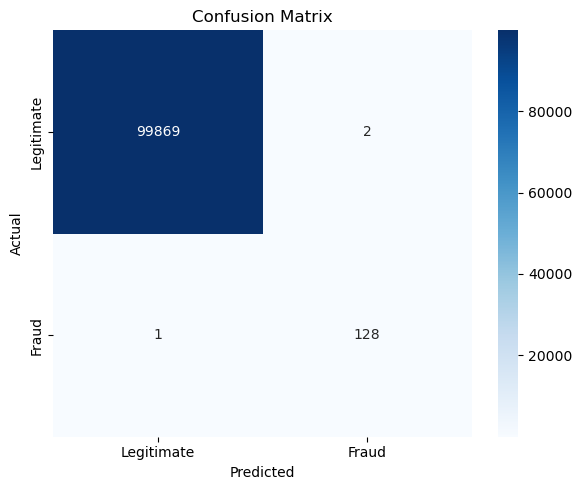

In [23]:
# ============================================================
# Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate","Fraud"],
    yticklabels=["Legitimate","Fraud"]
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

save_chart("01_confusion_matrix.png")

plt.show()

### Observation

The confusion matrix demonstrates excellent classification performance. Out of **100,000** testing transactions, the Random Forest model correctly classified **99,869** legitimate transactions and **128** fraudulent transactions. Only **2** legitimate transactions were incorrectly classified as fraud (false positives), and **1** fraudulent transaction was incorrectly classified as legitimate (false negative).

### Interpretation

The confusion matrix indicates that the model is highly effective in distinguishing fraudulent transactions from legitimate ones while maintaining an extremely low number of classification errors. Such performance is desirable in financial fraud detection, where minimizing missed fraud cases and unnecessary fraud alerts is essential.

## 15. ROC Curve

### Purpose

Evaluate the model's ability to distinguish between fraudulent and legitimate transactions across different classification thresholds.

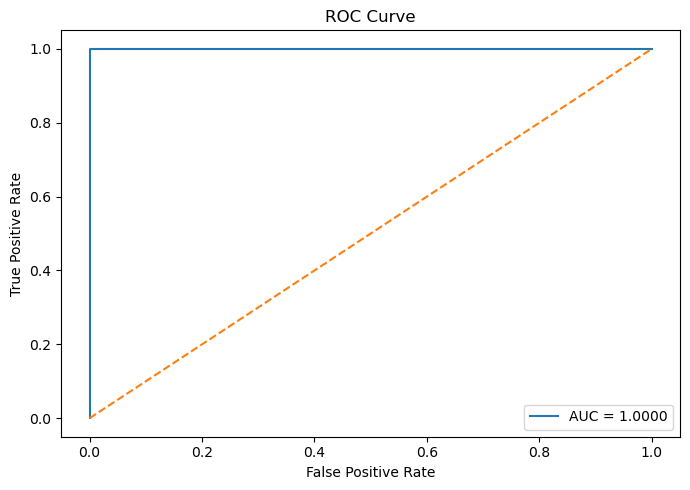

In [24]:
# ============================================================
# ROC Curve
# ============================================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

save_chart("02_roc_curve.png")

plt.show()

### Observation

The ROC curve closely follows the upper-left corner of the graph and achieves an **Area Under the Curve (AUC) of 1.0000**, indicating near-perfect discrimination between fraudulent and legitimate transactions.

### Interpretation

A high ROC-AUC score demonstrates that the model effectively ranks fraudulent transactions above legitimate ones across different decision thresholds. This confirms the model's strong predictive capability and robustness for fraud detection.

## 16. Feature Importance

### Purpose

Identify the variables that contribute most significantly to fraud prediction. Understanding feature importance improves model interpretability and supports business decision-making.

In [17]:
# ============================================================
# Feature Importance
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
10,balanceOrigDiff,0.300733
12,amount_to_balance_ratio,0.235342
4,newbalanceOrig,0.089922
6,newbalanceDest,0.074056
11,balanceDestDiff,0.069732
3,oldbalanceOrg,0.046472
0,step,0.036641
9,day,0.030764
2,amount,0.027610
8,hour,0.022531


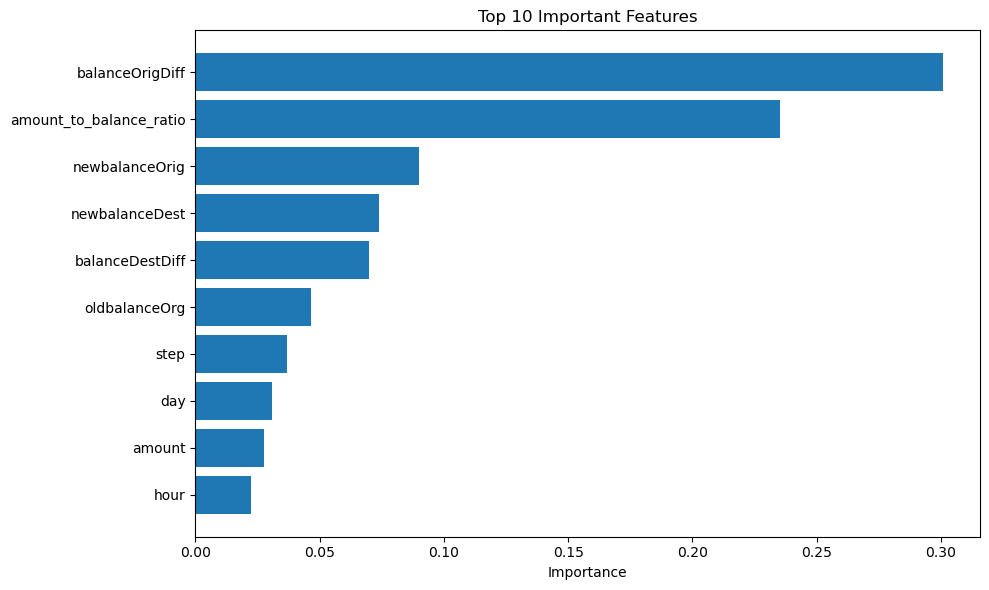

In [25]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:10],
    importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")

plt.title("Top 10 Important Features")

save_chart("03_feature_importance.png")

plt.show()

### Observation

The feature importance analysis reveals that **balanceOrigDiff** is the most influential predictor of fraudulent transactions, followed by **amount_to_balance_ratio**, **newbalanceOrig**, **newbalanceDest**, and **balanceDestDiff**. Temporal features such as **step**, **day**, and **hour** also contribute to the model, although their influence is comparatively lower.

### Interpretation

The results indicate that changes in account balances and transaction behavior are the primary indicators of fraudulent activity. While transaction timing contributes additional information, financial behavior-related features have the greatest impact on the model's decision-making process.

## 17. Save Trained Model

### Purpose

Save the trained Random Forest model for future fraud prediction without retraining the model.

In [19]:
# ============================================================
# Save Model
# ============================================================

joblib.dump(
    rf_model,
    "../models/fraud_detection_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


## 18. Isolation Forest for Anomaly Detection

### Purpose

Isolation Forest is an unsupervised anomaly detection algorithm designed to identify rare and unusual observations. Since fraudulent financial transactions are significantly less frequent than legitimate transactions, Isolation Forest provides an alternative AI-based approach for detecting suspicious activities without relying solely on labeled data.

In [20]:
# ============================================================
# Isolation Forest
# ============================================================

iso_model = IsolationForest(
    contamination=0.001,
    random_state=42
)

iso_model.fit(X_train)

print("Isolation Forest Model Trained Successfully.")

Isolation Forest Model Trained Successfully.


In [21]:
# ============================================================
# Save Models
# ============================================================

joblib.dump(
    rf_model,
    "../models/random_forest_model.pkl"
)

joblib.dump(
    iso_model,
    "../models/isolation_forest_model.pkl"
)

print("Models saved successfully.")

Models saved successfully.


## 20. Project Summary

### Summary

The AI-Driven Financial Fraud Analytics System was successfully developed using a structured data analytics and machine learning workflow. The project included data understanding, exploratory data analysis, feature engineering, data preprocessing, and predictive modeling.

A Random Forest classifier was trained to detect fraudulent financial transactions and achieved excellent predictive performance, with an Accuracy of **100.00%**, Precision of **98.46%**, Recall of **99.22%**, F1-Score of **98.84%**, and an ROC-AUC Score of **1.0000**.

In addition, an Isolation Forest anomaly detection model was implemented to identify unusual transaction patterns using an unsupervised AI approach. The trained models were saved for future deployment and can be integrated with business intelligence dashboards and real-time fraud monitoring systems.

Overall, the project demonstrates how artificial intelligence, feature engineering, and data analytics can be combined to build an effective financial fraud detection solution.